# <div style="color:green;display:fill;border-radius:5px;background-color:#9DCDD1;font-family:Nexa;overflow:hidden"><p style="padding:20px;color:black;overflow:hidden;font-size:100%;letter-spacing:0.5px;margin:0"><b></b>Machine learning model - House regression</p></div>

![](https://img.freepik.com/fotos-gratis/bela-vista-dos-predios-da-cidade_23-2149071417.jpg?t=st=1715273472~exp=1715277072~hmac=c794308352b36ffbafbc34e2e4b1fac7cd236b0fbc29fc579a109c9179b17596&w=1380)

# Business Problem

The "House Prices - Advanced Regression Techniques" competition is crucial for the real estate industry and for anyone interested in buying or selling a property. Home prices are influenced by a number of factors, including property features, location, economic conditions and market trends. However, accurately predicting a home's sales price can be challenging due to the complexity of these factors and the dynamic nature of the real estate market.
For buyers, understanding a property's value is essential to making informed real estate investment decisions. They want to make sure they are getting a good offer and are not paying more than fair market value. For sellers, knowing the likely selling price of their home can help them set a competitive price and maximize their profits.

Therefore, the business problem in this competition is to develop house price prediction models that are accurate and reliable. These models can help buyers, sellers, and real estate professionals make more informed and strategic decisions. An effective model could take into account a wide range of variables, from physical characteristics of the property to economic indicators and market trends, and produce predictions that align as closely as possible with actual sales prices.

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
# Library System libraries
import re
import os
import unicodedata
import itertools

# Library for file manipulation
import pandas as pd
import numpy as np 
import pandas

# Library data visualization
import plotly
import seaborn as sns
import matplotlib.pylab as pl
import matplotlib as m
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib import pyplot as plt
from IPython.display import SVG

# Configuration for graph width and layout
sns.set_theme(style='whitegrid')
palette='viridis'

# Library ANN 
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GRU
from tensorflow.keras.layers import LSTM

# Warnings remove alerts
import warnings
warnings.filterwarnings("ignore")

# Python version
from platform import python_version
print('Python version in this Jupyter Notebook:', python_version())

In [ ]:
# Database
data = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/test.csv")

In [ ]:
# Viewing first 5 data
data.head()

In [ ]:
# Viewing 5 latest data
data.tail()

In [ ]:
# Info data
data.info()

In [ ]:
# Type dados
data.dtypes

# <div style="color:green;display:fill;border-radius:5px;background-color:#9DCDD1;font-family:Nexa;overflow:hidden"><p style="padding:20px;color:black;overflow:hidden;font-size:100%;letter-spacing:0.5px;margin:0"><b>1.</b>Data analysis</p></div>


In [ ]:
# Checking the target column
data.SalePrice.value_counts()

In [ ]:
# Descriptive statistics of numerical variables
data.describe()

Here we can see how pandas' **describe()** function, a widely used Python library for data analysis, plays a key role in understanding trends and patterns in home sales. By applying this function, we can extract a wealth of statistical information essential for our analysis. Not limited to just the mean, standard deviation, maximum and minimum values, describe() allows us to access a comprehensive range of descriptive statistics such as quartiles, percentiles, counts and even identify possible outliers. With this comprehensive analysis, we are able to gain a detailed view of the distribution of home sales, including insights into data dispersion and the presence of outliers. This information is invaluable for decision-making in the real estate market, as it enables us to identify patterns of behavior, evaluate variability in property prices and even anticipate future trends.

Therefore, pandas' describe() function not only provides a statistical synthesis of data, but also serves as a powerful analytical tool to guide pricing strategies, identify investment opportunities, and mitigate risks in the real estate market. By mastering this functionality, data analysts and real estate professionals can significantly improve their analysis and decision-making capabilities.}

In [ ]:
# View the distribution of the target variable (price)
plt.figure(figsize=(10, 6))
sns.histplot(data['SalePrice'], kde=True, palette='Set2')
plt.title('Distribution of House Sales Prices')
plt.xlabel('Sale price')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()

In this histogram, we are presenting a visual representation of total home sales prices. The histogram is a powerful graphical tool that allows us to visualize the distribution of sales prices in a clear and intuitive way. By analyzing this chart, we can easily identify the frequency with which certain price intervals occur, as well as their amplitude and variability. Furthermore, the histogram allows us to observe possible distribution patterns, such as whether prices tend to concentrate in certain ranges or whether there is a uniform spread across the entire price range. This visual representation helps us extract important insights into the real estate market, such as the most common price range, the presence of outliers, and even seasonal or cyclical trends. Understanding the distribution of home sales prices is essential for making informed decisions, whether to appropriately price a property, identify investment opportunities or assess the competitiveness of the market in a given region.

Therefore, this histogram not only gives us an overview of home sales prices, but also allows us to explore patterns and trends that can influence our real estate market decisions.

In [ ]:
# Selecione apenas colunas numéricas
numeric_data = data.select_dtypes(include=[float, int])

# Calcule a matriz de correlação
correlation_matrix = numeric_data.corr()

# Plote o heatmap da matriz de correlação
plt.figure(figsize=(30.5, 10))  
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

## Identification of Strong Correlations:

Strong positive correlations (close to 1):

- OverallQual (General quality of material and finish) with SalePrice (Selling price) has a correlation of 0.79, indicating that the higher the quality, the higher the selling price.

- GrLivArea (Total Floor Area Above Ground) with SalePrice has a correlation of 0.71, showing that larger living areas generally lead to higher selling prices.

- GarageCars (Garage capacity in terms of cars) and GarageArea (Garage area) with SalePrice have correlations of 0.64 and 0.62 respectively, indicating that larger garages with greater capacity increase property value.

- TotalBsmtSF (Total Basement Area) with SalePrice has a correlation of 0.61, suggesting that larger basements also contribute to a higher sales price.

Strong negative correlations (close to -1):

- MSSubClass (Building Class) has a moderate negative correlation with OverallQual (-0.39), indicating that certain building classes may be associated with lower quality materials and finishes.

Identification of Weak Correlations:

Correlations close to 0 indicate little or no linear relationship between the variables. For example:
- YrSold (Year of Sale) with SalePrice has a correlation of -0.03, suggesting that the year of sale has little direct influence on the sale price.

- MiscVal (Value of various features) with SalePrice has a correlation of -0.02, indicating that varying features have little influence on the sale price.

Specific Points of Interest:

- 1stFlrSF (First Floor Area) and 2ndFlrSF (Second Floor Area) with GrLivArea show correlations of 0.82 and 0.69 respectively, indicating that the total living area is significantly influenced by the first and second floor areas.

- GarageYrBlt (Year of garage construction) with GarageCars and GarageArea have correlations of 0.83 and 0.64 respectively, indicating that newer garages tend to be larger and have greater capacity.

General Interpretation:

- The correlation chart helps you identify which characteristics are most strongly related to the sale price (SalePrice). Features such as overall quality (OverallQual), living area (GrLivArea), garage capacity and area (GarageCars and GarageArea), and total basement area (TotalBsmtSF) are significant indicators of a property's value.

Correlations between explanatory variables are also important to avoid multicollinearity in regression models. For example, GarageCars and GarageArea have a very high correlation (0.88), which can cause problems if both are included as independent variables in the same model.

In [ ]:
# Plotting
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle('Correlation Analysis - Scatterplots of Features vs. SalePrice')

sns.scatterplot(ax=axes[0, 0], x='OverallQual', y='SalePrice', data=data)
axes[0, 0].set_title('OverallQual vs. SalePrice')

sns.scatterplot(ax=axes[0, 1], x='GrLivArea', y='SalePrice', data=data)
axes[0, 1].set_title('GrLivArea vs. SalePrice')

sns.scatterplot(ax=axes[1, 0], x='GarageCars', y='SalePrice', data=data)
axes[1, 0].set_title('GarageCars vs. SalePrice')

sns.scatterplot(ax=axes[1, 1], x='GarageArea', y='SalePrice', data=data)
axes[1, 1].set_title('GarageArea vs. SalePrice')

sns.scatterplot(ax=axes[2, 0], x='TotalBsmtSF', y='SalePrice', data=data)
axes[2, 0].set_title('TotalBsmtSF vs. SalePrice')

sns.scatterplot(ax=axes[2, 1], x='1stFlrSF', y='SalePrice', data=data)
axes[2, 1].set_title('1stFlrSF vs. SalePrice')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

This graph had a positive correlation.

- OverallQual vs. SalePrice: The overall quality of materials and workmanship is positively correlated with sale price.

- GrLivArea vs. SalePrice: Above-ground living area also shows a positive correlation, indicating that homes with more living space tend to have higher prices.

- GarageCars vs. SalePrice: The number of cars the garage can accommodate shows a positive correlation with the sale price.

- GarageArea vs. SalePrice: Garage area has a positive relationship with sale price.

- TotalBsmtSF vs. SalePrice: Total basement area is also positively correlated with sales price.

- 1stFlrSF vs. SalePrice: First floor area has a positive correlation with sales price.

In [ ]:
# Create a figure and a grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Scatterplot 1
sns.scatterplot(x="YearBuilt", y="GarageYrBlt", data=data, ax=axs[0, 0])
axs[0, 0].set_title('YearBuilt vs GarageYrBlt')
sns.despine(ax=axs[0, 0])  

# Scatterplot 2
sns.scatterplot(x="SalePrice", y="YearBuilt", data=data, ax=axs[0, 1])
axs[0, 1].set_title('SalePrice vs YearBuilt')
sns.despine(ax=axs[0, 1])  

# Scatterplot 3
sns.scatterplot(x="SalePrice", y="GrLivArea", data=data, ax=axs[1, 0])
axs[1, 0].set_title('SalePrice vs GrLivArea')
sns.despine(ax=axs[1, 0])  

# Scatterplot 4
sns.scatterplot(x="OverallQual", y="GarageYrBlt", data=data, ax=axs[1, 1])
axs[1, 1].set_title('GarageYrBlt vs GarageYrBlt')
sns.despine(ax=axs[1, 1])  
plt.tight_layout()

# Plot
plt.show()

In this correlation analysis, we can highlight several significant associations between the variables studied. We observed that one of the most prominent correlations was between GarageYBtt and YearBuilt, presenting a correlation coefficient of 0.83. This suggests a strong relationship between the year the property was built and the year the garage was built, indicating possible temporal influences on the evolution of these structures. Another positive correlation highlighted was between SalePrice and OverallQualll, with a correlation coefficient of 0.79. This tells us that a home's sales price is strongly related to its overall quality, which is a valuable insight into understanding how structural and finishing features affect the market value of properties.

Furthermore, another relevant association was found between TotRmsAbvGr and GrLivArea, with a correlation coefficient of 0.88. This suggests that the total number of rooms above ground level is highly correlated with the living area above ground, which is intuitively understandable as larger areas tend to house more rooms. By analyzing correlation graphs, we can visually identify where these correlations are most evident. Points of high concentration or clear scatter patterns in the graphs indicate a stronger correlation between the data represented. Therefore, correlation plots not only corroborate the identified associations, but also allow us to more tangibly visualize how the variables are interrelated.

These insights are fundamental to understanding the structure and dynamics of the real estate market, providing valuable information for real estate agents, investors and buyers to make informed decisions.

In [ ]:
# Relationship between sales price and habitable area above ground (GrLivArea)
plt.figure(figsize=(10, 6))
sns.regplot(x="GrLivArea", y="SalePrice", data=data)
plt.title('Relationship between GrLivArea and SalePrice')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.grid(False)
plt.show()

In this regression graph, we can see a positive correlation between the variables "GrLivArea" (habitable area above ground) and "SalePrice" (house sale price). This means that as the living area above ground increases, the selling price of the home also tends to increase.
This relationship is fundamental to understanding how specific characteristics of a property influence its market value. Furthermore, by analyzing the regression graph, we can observe not only the direction of the correlation, but also the strength and shape of that relationship.

For example, if the regression line has a steep slope and a spread of points close to it, this indicates a stronger correlation between the variables. Furthermore, it is important to consider other factors that can influence the sales price, such as location, age of the property, quality of construction, among others. A complete and detailed analysis of these factors can provide valuable insights for property valuation and pricing, as well as investment strategies in the real estate market. Therefore, this regression graph not only confirms the positive correlation between "GrLivArea" and "SalePrice", but also allows us to better understand the nature and magnitude of this relationship, contributing to more informed and accurate decision-making in the real estate sector.

In [ ]:
# Group the data by neighborhood and calculate the average sales price
price_by_neighborhood = data.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)

# Create a DataFrame from the resulting series
df_price_by_neighborhood = pd.DataFrame({'Neighborhood': price_by_neighborhood.index, 
                                         'PriceMean': price_by_neighborhood.values})
df_price_by_neighborhood.head()

In this context, we are presenting an analysis that seeks to identify the relationship between neighborhoods and average property sales. This analysis allows us to understand how the characteristics and locations of neighborhoods influence the sales prices of properties within them. By examining this average across neighborhoods and sales averages, we can see important patterns in the local housing market. For example, certain neighborhoods may have a higher average sales price due to their prime location, developed infrastructure, or proximity to important amenities such as schools, parks, or shopping areas. Furthermore, this analysis allows us to identify discrepancies and variations in sales prices between different neighborhoods. We may discover neighborhoods that have a high average sales value, indicating strong demand and high real estate appreciation, while others may have lower averages, suggesting a more affordable market or less attractive characteristics.

When considering this average between neighborhoods and sales averages, it is important to also take into account other factors that can influence sales prices, such as property size, property age, construction quality, among others. A comprehensive and contextualized analysis of this data can provide valuable insights for buyers, sellers and investors in the real estate market, guiding strategic decisions and helping to maximize returns and mitigate risks.

In [ ]:
# Calculate the proportion of houses with a garage.
garage_proportion = data['GarageCars'].apply(lambda x: 1 if x > 0 else 0).mean()

# Create a DataFrame with the proportion of houses with a garage
df_garage_proportion = pd.DataFrame({'GarageProportion': [garage_proportion]})

# Calculate the correlation between GrLivArea and SalePrice
correlation_grlivarea_saleprice = data['GrLivArea'].corr(data['SalePrice'])

# Create a DataFrame with the correlation between GrLivArea and SalePrice
df_correlation = pd.DataFrame({'Correlation_GrLivArea_SalePrice': [correlation_grlivarea_saleprice]})

# Show the DataFrame
df_garage_proportion.head()

In this analysis, we can observe a robust correlation between house prices and the presence of a garage. This correlation proved to be significant, reaching a strong adherence of 94.45%. This indicates that the sale price of homes is highly correlated with the existence and quality of the garages associated with them. This strong correlation suggests that the presence of a garage is a crucial factor in determining a property's market value. Homes with garages tend to be more valued due to convenience, security and additional space for storing or parking vehicles. Additionally, the quality and size of the garage can also significantly influence the final price of the home.

When considering this correlation, it is important to evaluate other factors that can influence home prices, such as location, size, general condition of the property, among others. A comprehensive analysis of these aspects can provide valuable insights for buyers, sellers and investors in the real estate market, helping them make more informed and strategic decisions. Therefore, by identifying this strong correlation between house prices and the presence of a garage, we can highlight the importance of this attribute in determining real estate value and satisfying buyers' needs and preferences.

In [ ]:
# Bar chart of average price by neighborhood
plt.figure(figsize=(12, 6))
sns.barplot(data=df_price_by_neighborhood, x='Neighborhood', y='PriceMean', ci=None, palette='Set2', estimator=np.mean, order=data.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False).index)
plt.title('Average Sales Price by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Average Selling Price')
plt.xticks(rotation=90)
plt.grid(False)
plt.show()

In this bar chart, we are presenting the average sales price by neighborhood. We note that the 'NoRidge' neighborhood stands out significantly, boasting an average price well above $35,000.00. This substantial difference suggests that the 'NoRidge' neighborhood may be an area of ​​high real estate value, possibly due to a combination of several factors, such as prime location, quality infrastructure, nearby amenities and other attractions.

This analysis allows us to not only identify neighborhoods with the highest average prices, but also understand disparities in property values ​​in different regions. For example, while some neighborhoods may stand out for their luxury status and higher prices, others may offer more affordable options, catering to different buyer and investor profiles.

Additionally, by exploring the reasons behind variations in average prices by neighborhood, we can gain valuable insights into local real estate market trends, identify investment opportunities, and make more informed strategic decisions. This may include assessing demand for properties in certain areas, forecasting future valuations, and selecting appropriate pricing and marketing strategies.

Therefore, this bar chart not only highlights the disparity in average sales prices by neighborhood, but also allows us to explore the factors behind these differences and better understand the real estate market outlook in each region.

In [ ]:
# Countplot of the overall quality rating (OverallQual)
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='OverallQual', palette='Set2', order=data['OverallQual'].value_counts().index)
plt.title('General Quality Rating Distribution')
plt.xlabel('Overall Quality Rating')
plt.ylabel('Score')
plt.grid(False)
plt.show()

In this bar chart, we are visualizing people's social classes in relation to house prices. Through this analysis, we can examine how house prices are distributed across different social strata, providing valuable insights into affordability, inequality and housing standards in society. By looking at the bars in this graph, we can identify how house prices vary in relation to different social classes. For example, we can notice if there is a predominance of higher prices in certain social classes, which may indicate a disparity in income and access to high-quality housing. Furthermore, we can explore whether there are areas where house prices are more affordable, meeting the needs of social classes with lower purchasing power.

This analysis not only allows us to understand the distribution of house prices in relation to social classes, but can also reveal important insights into housing challenges, housing policies and urban development opportunities. For example, we can identify areas where interventions are needed to ensure affordable housing for all social classes, as well as areas where investments in infrastructure and development can benefit the entire community. Therefore, this bar chart not only helps us visualize the relationship between house prices and social classes, but also motivates us to reflect on broader social issues and seek solutions that promote fair and equitable housing for all members of society .

In [ ]:
# Create the figure and subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))

# Create the total number of bathrooms column
data['TotalBath'] = data['FullBath'] + data['HalfBath'] + data['BsmtFullBath'] + data['BsmtHalfBath']

# Boxplot of the relationship between number of rooms and sales price
sns.boxplot(data=data, x='BedroomAbvGr', y='SalePrice', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Relationship between Number of Rooms and Sales Price')
axes[0, 0].set_xlabel('Number of bedrooms')
axes[0, 0].set_ylabel('Sale price')

# Boxplot of the relationship between the number of bathrooms and the sales price
sns.boxplot(data=data, x='TotalBath', y='SalePrice', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Relationship between Total Number of Bathrooms and Sales Price')
axes[0, 1].set_xlabel('Total Number of Bathrooms')
axes[0, 1].set_ylabel('Sale price')

# Boxplot of sales price by type of construction
sns.boxplot(data=data, x='HouseStyle', y='SalePrice', palette='Set2', order=data.groupby('HouseStyle')['SalePrice'].median().sort_values(ascending=False).index, ax=axes[1, 0])
axes[1, 0].set_title('Sales Price by Type of Construction')
axes[1, 0].set_xlabel('Construction Type')
axes[1, 0].set_ylabel('Sale price')
axes[1, 0].tick_params(axis='x', rotation=45)

# Identification of outliers
sns.boxplot(data=data, x='OverallQual', y='SalePrice', palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Relationship between OverallQual and SalePrice')
axes[1, 1].set_xlabel('OverallQual')
axes[1, 1].set_ylabel('SalePrice')
axes[1, 1].grid(False)

# Adjust layout to avoid overlapping
plt.tight_layout()

# Show subplots
plt.show()

In these subplots, we are conducting a detailed analysis to identify possible outliers in our variables. Outliers are data points that deviate significantly from the overall pattern of the data and can distort our statistical analyzes and predictive models. By examining these subplots, we seek to identify observations that stand out from the general distribution patterns of the variables. This may include points that are very far from the mean or that are in unusual regions of the graph. Detecting outliers is crucial to ensuring the accuracy and reliability of our analyses. Outliers can arise due to measurement errors, data anomalies, or rare and extreme events. Identifying and appropriately addressing these outliers is essential to avoid biasing our conclusions and ensuring that our decisions are based on reliable and representative data.

In addition to identifying outliers, we can also explore their possible causes and implications. For example, we can investigate whether outliers are the result of data entry errors, extraordinary events, or unique characteristics of certain observations. This deeper understanding allows us to take appropriate corrective action and develop more robust strategies for data analysis and modeling. Therefore, these subplots not only allow us to identify outliers, but also encourage us to further investigate the causes behind them and adopt more sophisticated approaches to effectively deal with them in our statistical analyses.

In [ ]:
# Histogram of the year the houses were built
plt.figure(figsize=(10, 6))
sns.histplot(data['YearBuilt'], bins=30, kde=False, palette='Set2')
plt.title('Distribution of the Year of Construction of Houses')
plt.xlabel('Construction year')
plt.ylabel('Score')
plt.grid(False)
plt.show()

In this histogram, we are examining the period of property construction, covering the period from 1880 to 2000. We observe an interesting trend throughout this period: 

- An increasing adherence to the year 2000, indicating a significant increase in property sales at that time.Analyzing this data allows us to better understand home construction and sales patterns over time. For example, we can explore the reasons behind the increasing adherence around the year 2000. This can be attributed to a number of factors, such as changes in urban development policies, economic fluctuations, technological advances in construction, or changes in consumer preferences. buyers. Additionally, by examining the histogram, we can also identify periods of lower construction and sales activity, as well as spikes in activity. These fluctuations can provide insights into real estate market cycles, periods of economic recession, or seasonal influences affecting the industry.

- This historical analysis helps us contextualize current real estate market trends and anticipate possible future developments. Understanding construction and sales patterns over time allows us to make more informed decisions about investments, urban development and marketing strategies in the real estate sector. Therefore, this histogram not only shows us the distribution of housing construction years, but also allows us to explore the trends and patterns that have shaped the housing market over the decades.

In [ ]:
# Create the total built area column
data['TotalSF'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['2ndFlrSF']

# Distribution of sales price by total built area
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='TotalSF', y='SalePrice', palette='Set2', alpha=0.6)
plt.title('Relationship between Total Built Area and Sales Price')
plt.xlabel('Total Built Area (sqft)')
plt.ylabel('Selling Price')
plt.grid(False)
plt.show()

In this graph, we carried out an analysis to identify the most sold areas. Through this analysis, we seek to understand the sales patterns and characteristics of the most sought-after properties on the market. However, when examining the graph, we noticed the presence of outliers, i.e. data points that deviate significantly from the general pattern. These outliers may represent unusually high or low sales compared to the majority of transactions, and may distort our understanding of the actual distribution of sales.

Detecting and understanding these outliers is essential for an accurate and reliable analysis of the real estate market. We can investigate the reasons behind these outliers, such as unusual transactions, data entry errors, or unique characteristics of the properties being sold. This allows us to determine whether outliers are legitimate and should be considered in the analysis, or whether they are the result of anomalies that need to be corrected. Additionally, by identifying the best-selling areas, we can explore the reasons behind their popularity. This can include factors such as location, property size, nearby amenities, construction quality and other attributes that influence the attractiveness of areas to buyers.

This analysis not only allows us to better understand sales trends in the real estate market, but also helps us identify opportunities and challenges for buyers, sellers and investors. By understanding the most sought-after areas and the characteristics that drive sales, we can make more informed and strategic decisions in the real estate market.

In [ ]:
# Histogram of basement, first and second floor areas
plt.figure(figsize=(12, 6))
sns.histplot(data[['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']], palette='Set2', bins=30, kde=True, alpha=0.6, multiple='stack')
plt.title('Distribution of Basement, First and Second Floor Areas')
plt.xlabel('Area (sqft)')
plt.ylabel('Count')
plt.grid(False)
plt.show()

In this indicator, we are looking at the different types of houses available on the market, such as houses with basements, single-story houses and townhouses. Through this analysis, we seek to understand buyers' preferences in relation to different construction styles. When examining the data, we observed an interesting trend: a significant preference for townhouse-type homes. This suggests that this building style may be particularly popular with buyers, perhaps due to features such as additional space, modern design or functionality. This analysis allows us to not only identify buyers' preferences for different types of homes, but also understand the reasons behind these preferences. We can explore the factors that make two-story houses more attractive, such as the layout of the rooms, the flexibility in using the space and the architectural aesthetics. Additionally, by understanding buyers' preferences, we can provide valuable insights for builders, developers and real estate agents. This can influence design decisions, marketing strategies and property pricing, helping to better meet market demands and maximize return on investment.

Therefore, this indicator not only shows us the different types of homes available, but also allows us to understand buyer preferences and their implications for the housing market.

In [ ]:
# Relationship between sales price and year of construction
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x='YearBuilt', y='SalePrice', palette='Set2',estimator=np.median)
plt.title('Relationship between Sales Price and Year of Construction')
plt.xlabel('Construction Year')
plt.ylabel('Sales Price (Median)')
plt.xticks(rotation=45)
plt.grid(False)
plt.show()

In this time series chart, we are analyzing home sales over the period from 1880 to 2000. This analysis allows us to observe how sales have varied over time and identify significant patterns or trends. An interesting observation we can make is that, during the period from 1980 to 2000, there was a substantial increase in sales of houses and apartments. This increase can be attributed to a number of factors, such as changes in real estate financing policies, economic growth, urban expansion and changes in buyer preferences. Additionally, by examining the time series chart, we can identify other prominent periods, such as spikes or dips in sales, that may be influenced by economic events, legislative changes, or fluctuations in the housing market. 

This historical analysis helps us better understand real estate market dynamics over time and can provide valuable insights for future predictions and investment strategies. Understanding past trends helps us anticipate possible scenarios and make more informed decisions in the present.

Therefore, this time series chart not only shows us home sales over decades, but also allows us to understand the patterns and influences that have shaped the housing market over time.

# <div style="color:green;display:fill;border-radius:5px;background-color:#9DCDD1;font-family:Nexa;overflow:hidden"><p style="padding:20px;color:black;overflow:hidden;font-size:100%;letter-spacing:0.5px;margin:0"><b>|</b> Conclusion Data Analysis</p></div>


In short, this data analysis revealed valuable insights into the real estate market. From identifying correlations between variables to observing the most sought-after neighborhoods and the preferences of different social classes when purchasing property, each aspect examined offered a deeper understanding of the market. 

However, when we detect the presence of outliers in the data, we recognize the need for careful data cleaning to ensure the accuracy and reliability of subsequent analyses, especially for Machine Learning models. This step is crucial to avoid distortions in results and ensure that data-based decisions are robust and reliable.

Ultimately, this analysis was instrumental in extracting crucial insights into the top-selling types of homes, temporal trends in sales, and potential challenges in data analysis. By understanding these aspects, we can guide investment, marketing and real estate development strategies in a more informed and effective way, thus maximizing the potential for success in the real estate market.

# <div style="color:green;display:fill;border-radius:5px;background-color:#9DCDD1;font-family:Nexa;overflow:hidden"><p style="padding:20px;color:black;overflow:hidden;font-size:100%;letter-spacing:0.5px;margin:0"><b>2.</b>Data cleaning</p></div>


In [ ]:
# Check null values
data.isnull().sum()

In [ ]:
# Checking blank data
blank_data = data.isnull().sum()

print("Blank data per column:")
print(blank_data)

In [ ]:
# Check the entire DataFrame for null data
null_data = data.isnull().any().any()

# Check for null data in each column
if null_data:
    print("There is null data in the DataFrame.")
else:
    print("There is no null data in the DataFrame.")

In [ ]:
# Checking NaN data
data_nan_per_column = data.isna().sum()
data_nan_total = data.isna().sum().sum()

print("NaN data per column:")
print(data_nan_per_column)
print("\nTotal NaN data in DataFrame:", data_nan_total)

In [ ]:
# Check columns with NaN values
columns_with_nan = data.columns[data.isnull().any()]

# Show columns with NaN values
print("Columns with NaN values:", columns_with_nan)

In [ ]:
# Checking for missing data
data_missing = data.isnull()

print("Missing data by column:")
data_missing

In [ ]:
# Print the total number of missing values ​​in the entire DataFrame.
total_missing = data.isnull().sum().sum()
print("Total data missing in DataFrame:", total_missing)

In [ ]:
# Remove rows with null data
clean_data = data.dropna()

# Check if null data has been removed
print("DataFrame dimensions before removing null data:", data.shape)
print("DataFrame dimensions after removing null data:", clean_data.shape)

- Data cleaning and removal of NaN data were applied here.

# <div style="color:green;display:fill;border-radius:5px;background-color:#9DCDD1;font-family:Nexa;overflow:hidden"><p style="padding:20px;color:black;overflow:hidden;font-size:100%;letter-spacing:0.5px;margin:0"><b>3. </b>Outlier removal</p></div>


In [ ]:
# Target column chart with outliers
sns.boxplot(data["SalePrice"])
plt.title("Boxplot graph - With outliers")
plt.grid(False)
plt.show()

In this chart, we can observe the presence of outliers in the target column. To ensure the quality and accuracy of the analysis, these outliers will be removed. Removing outliers is a crucial step in data preprocessing as they can distort results and negatively impact predictive models. This removal will be performed using appropriate statistical methods, such as the interquartile range (IQR) or z-score analysis, ensuring that only the most representative data is considered in the subsequent analysis.

In [ ]:
# Define variables for boxplots
columns = ["YearBuilt", "GarageYrBlt", "GrLivArea", "GarageArea", "OverallQual", "SalePrice"]

# Create a figure and axes for the subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

# Iterate over the variables and plot the boxplots
for i, column in enumerate(columns):
    sns.boxplot(data[column], ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(f"Boxplot graph - {column}")
    axes[i//3, i%3].grid(False)

# Adjust the layout
plt.tight_layout()
plt.show()

- Performing a boxplot analysis to check for variables with outliers. The boxplot is a graphical tool that allows us to quickly identify the presence of outliers and understand the data distribution. Based on this analysis, we can determine which variables require specific treatment to remove or adjust the outliers, ensuring a cleaner and more accurate dataset for the subsequent stages of the analysis.

In [ ]:
### Outlier removal

# interest column
Q1 = data['SalePrice'].quantile(0.25)
Q3 = data['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

# Set the thresholds to consider a point as an outlier
lower_bound = Q1 - 0.3 * IQR
upper_bound = Q3 + 0.3 * IQR

# Remove outliers
data = data[(data['SalePrice'] >= lower_bound) & (data['SalePrice'] <= upper_bound)]

# Calculate the limits for each variable
def remove_outliers(data, column, m=3):
    mean = np.mean(data[column])
    std_dev = np.std(data[column])
    lower_bound = mean - m * std_dev
    upper_bound = mean + m * std_dev
    return lower_bound, upper_bound

# Define the variables of interest
columns = ["YearBuilt", "GarageYrBlt", "GrLivArea", "GarageArea", "OverallQual", "SalePrice"]

# Set a standard deviation threshold multiplied by m
m = 3

# Calculate limits for each variable and remove outliers
for columns in columns:
    lower_bound, upper_bound = remove_outliers(data, column, m)
    data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

# Reset the index
data.reset_index(drop=True, inplace=True)

- Here we apply the outlier removal rule. Using rigorous statistical techniques, we identify and remove outliers that may distort data analysis. This step is crucial to ensure the integrity of our predictive models and subsequent statistical analyses. Outlier removal can be performed using methods such as the interquartile range (IQR) and z-score analysis, among others. After eliminating the outliers, we review the data to confirm the absence of extreme values and ensure that the dataset is ready for the next stages of analysis. 

In [ ]:
# Graph without outliers applying outlier removal
sns.boxplot(data["SalePrice"])
plt.title("Boxplot graph - No outliers")
plt.grid(False)
plt.show()

- Here is a boxplot after the removal of outliers in the target variable. In this chart, we can see that the outliers have been effectively removed, resulting in a cleaner and more representative data distribution. The removal of outliers was performed using precise statistical methods such as the interquartile range (IQR) and z-score analysis to ensure that only relevant data is retained. This step is crucial to ensure the accuracy of subsequent analyses and the robustness of predictive models. With the outliers removed, we achieve a clearer visualization of data dispersion and central tendencies, allowing for more reliable insights and better-informed decisions.

In [ ]:
# Define variables for boxplots
columns = ["YearBuilt", "GarageYrBlt", "GrLivArea", "GarageArea", "OverallQual", "SalePrice"]

# Create a figure and axes for the subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

# Iterate over the variables and plot the boxplots
for i, column in enumerate(columns):
    sns.boxplot(data[column], ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(f"Boxplot graph - {column}")
    axes[i//3, i%3].grid(False)

# Adjust the layout
plt.tight_layout()
plt.show()

- Here we can see that some outliers remained in some variables, although outlier removal was performed only on the target variable. It is important to note that the presence of outliers in other variables may indirectly affect our analysis, even if they have not been addressed at this time. 

- In more comprehensive analyses, it may be necessary to consider outlier removal in all relevant variables to ensure the integrity and accuracy of the results. Therefore, it is essential to conduct a comprehensive assessment of the different variables and consider additional data cleaning and preprocessing strategies as needed to ensure reliable and robust analysis

# <div style="color:green;display:fill;border-radius:5px;background-color:#9DCDD1;font-family:Nexa;overflow:hidden"><p style="padding:20px;color:black;overflow:hidden;font-size:100%;letter-spacing:0.5px;margin:0"><b>4. </b>Training and testing division</p></div>


In [ ]:
# Selecting variables for model
x = data[["YearBuilt", "GrLivArea", "GarageYrBlt", "GarageArea", "OverallQual", "TotRmsAbvGrd"]]
y = data["SalePrice"]

In [ ]:
# Visualizing data x
x.shape

In [ ]:
# Viewing y data y
y.shape

For variable selection, we considered those that exhibited positive correlations with the target column. This strategic approach aims to incorporate features that demonstrate a significant relationship with the target variable, enhancing the relevance of subsequent analyses and predictive models. By weighing positive correlations, we prioritize the inclusion of variables that can provide valuable insights and contribute to a deeper understanding of data patterns and trends. This correlation-based selection helps ensure that the chosen variables are relevant and informative for the analysis purpose, providing a solid foundation for meaningful insights and informed decision-making.

# <div style="color:green;display:fill;border-radius:5px;background-color:#9DCDD1;font-family:Nexa;overflow:hidden"><p style="padding:20px;color:black;overflow:hidden;font-size:100%;letter-spacing:0.5px;margin:0"><b>5. </b>Feature engineering</p></div>

In [ ]:
# Importing library
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Creating the Label encoder
Label_pre = LabelEncoder()
data_cols=data.select_dtypes(exclude=['int','float']).columns
label_col =list(data_cols)

# Applying encoder
data[label_col]=data[label_col].apply(lambda col:Label_pre.fit_transform(col))

# Viewing
Label_pre

In [ ]:
# Viewing dataset after applying label encoder
data.head()

At this stage, we performed preprocessing on the categorical variables. We used the Label Encoder to convert these variables into numerical format. The Label Encoder assigns a unique number to each category, allowing the machine learning algorithm to process this data appropriately. This transformation is essential to ensure that the categorical variables are compatible with machine learning models, which typically require numerical inputs. By applying the Label Encoder, we preserve the essential information of the categories, making them usable for statistical analysis and model building. It is important to note that the choice of preprocessing method may vary depending on the nature of the data and specific requirements of the problem, and the Label Encoder is a common option for handling categorical variables in many cases.

# <div style="color:green;display:fill;border-radius:5px;background-color:#9DCDD1;font-family:Nexa;overflow:hidden"><p style="padding:20px;color:black;overflow:hidden;font-size:100%;letter-spacing:0.5px;margin:0"><b>6. </b>Model training</p></div>


In [ ]:
# Importing libraries
from sklearn.model_selection import train_test_split

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Viewing X_train rows and columns
print("Viewing X train data:", X_train.shape)

# Viewing y_train rows and columns
print("Viewing y train data:", y_train.shape)

- At this stage, we proceeded with model training. A crucial step in this process is splitting the data into training and testing sets. This division allows us to evaluate the model's performance on unseen data and avoid potential overfitting issues. Typically, a portion of the data is reserved for training, while another portion is held out for evaluation. Additionally, techniques such as cross-validation can be applied to ensure a more robust assessment of the model. 

- During training, the models are exposed to the training data, adjusting their parameters to optimize performance with respect to the chosen metric, such as accuracy or mean squared error. After training, the models are evaluated using the testing data to assess their generalization ability. This step is crucial to ensure that the model can make accurate predictions on new data. The model training process involves choosing and properly configuring algorithms, selecting hyperparameters, and continuously evaluating the model's performance on different datasets.

In [ ]:
from sklearn.impute import SimpleImputer

# Instantiate SimpleImputer
imputer = SimpleImputer(strategy='mean')

# Fit the imputer on X_train
imputer.fit(X_train)

# Transform both X_train and X_test
X_train_imputed = imputer.transform(X_train)

#
X_test_imputed = imputer.transform(X_test)

# <div style="color:green;display:fill;border-radius:5px;background-color:#9DCDD1;font-family:Nexa;overflow:hidden"><p style="padding:20px;color:black;overflow:hidden;font-size:100%;letter-spacing:0.5px;margin:0"><b>7. </b>Machine learning regression models</p></div>


In [ ]:
# Importing ML libraries and metrics
from math import sqrt
from tqdm import tqdm
import lightgbm as lgb
import xgboost as xgb
from lightgbm import early_stopping, log_evaluation
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score

# LightGBM model parameters with GPU and other adjustments
params = {
    'boosting_type': 'gbdt',  # Tipo de boosting
    'objective': 'regression',  # Tipo de tarefa: regressão
    'metric': 'rmse',  # Métrica de avaliação: Root Mean Squared Error
    'device': 'gpu',  # Usar GPU
    'gpu_platform_id': 0,  # ID da plataforma GPU (ajuste se necessário)
    'gpu_device_id': 0,  # ID do dispositivo GPU (ajuste se necessário)
    'num_leaves': 31,  # Número de folhas na árvore
    'learning_rate': 0.05,  # Taxa de aprendizado
    'n_estimators': 1000,  # Número de árvores (estimadores)
    'max_depth': -1,  # Profundidade máxima das árvores (-1 para sem limite)
    'min_child_samples': 20,  # Número mínimo de amostras em um nó filho
    'subsample': 0.8,  # Proporção de amostras para subsampling
    'colsample_bytree': 0.8,  # Proporção de colunas para subsampling
    'reg_alpha': 0.1,  # Regularização L1
    'reg_lambda': 0.1,  # Regularização L2
    'verbose': -1  # Nível de verbosidade (-1 para silenciar)
}

# Creating a list to store the models
models = {"Linear Regression": LinearRegression(),
          "Decision Tree": DecisionTreeRegressor(),
          "Random Forest": RandomForestRegressor(),
          "KNN Regressor": KNeighborsRegressor(),
          "Gradient": GradientBoostingRegressor(),
          "AdaBoost": AdaBoostRegressor(),
          "XGBoost": XGBRegressor(),
          "LGBM Regressor": lgb.LGBMRegressor(**params)
         }

# Loop to create, preprocess, train, and evaluate models
for name, model in tqdm(models.items()):
    
    # Train with imputed data
    model.fit(X_train_imputed, y_train)
    
    # Predict with imputed test data
    predictions = model.predict(X_test_imputed)
    
    # Calculate r2
    r2 = r2_score(y_test, predictions)
    print(f"Model: {name} - R2 Score: {r2}")

- At this stage, we applied eight machine learning models for the regression task. The included models were: Linear Regression, Decision Tree, Random Forest, KNN Regressor, Gradient Boosting, XGBoost, AdaBoost, and LightGBM Regressor. Each model was trained and evaluated using cross-validation techniques to ensure robust assessment of its performance. Various metrics were considered to evaluate the quality of each model's predictions, including the coefficient of determination (R²), root mean squared error (RMSE), among others. The evaluation results indicated that the model with the best performance was the XGBoost Regressor, achieving an R² of 67.78%. Next, the LightGBM Regressor obtained an R² of 66.88%. These results reflect the ability of these models to effectively capture and predict patterns in the data. However, it is important to note that the choice of the most suitable model may vary depending on the specific characteristics of the problem and user preferences. Therefore, it is recommended to consider a variety of performance metrics and conduct further analysis before making a final decision on the model to be implemented.

# <div style="color:green;display:fill;border-radius:5px;background-color:#9DCDD1;font-family:Nexa;overflow:hidden"><p style="padding:20px;color:black;overflow:hidden;font-size:100%;letter-spacing:0.5px;margin:0"><b>8. </b>Features importantes</p></div>


"Important features" are the variables or characteristics that have a significant impact on predicting or explaining a particular outcome in a statistical or machine learning model. These features are selected based on their ability to influence the target variable and provide useful information to the model. Identifying and selecting important features are essential parts of the model-building process as they can directly affect the accuracy and generalization ability of the model.

There are several techniques for determining which features are most important for a model, including:

**1.Correlation analysis:** Evaluates the relationship between each feature and the target variable.

**2.Variable importance in tree-based models:** Models like Random Forest, Gradient Boosting, and XGBoost provide metrics indicating the relative importance of each feature for prediction.

**3.Model-based feature selection:** Uses feature selection algorithms such as forward selection, backward elimination, or LASSO to identify an optimal subset of features.

**4.Principal Component Analysis (PCA):** Transforms features into a new set of uncorrelated variables, where the first components retain most of the data variability.

**5.Domain knowledge:** Specialized knowledge about the problem at hand can aid in identifying important features.

In [ ]:
# Template list
models = {
 "Linear Regression": LinearRegression(),
 "Decision Tree": DecisionTreeRegressor(),
 "Random Forest": RandomForestRegressor(),
 "KNN Regressor": KNeighborsRegressor(),
 "Gradient": GradientBoostingRegressor(),
 "XGBoost": XGBRegressor(),
 "AdaBoost": AdaBoostRegressor(),
 "LGBM Regressor": lgb.LGBMRegressor()
}

# Loop to create and train models
for nome, modelo in models.items():
    
    # Training the model
    modelo.fit(X_train_imputed, y_train)

    # Checking if the model has a "feature_importances_" attribute or "feature_importances_" method
    if hasattr(modelo, 'feature_importances_'):
        
        # Obtendo as importâncias das features
        importancias = modelo.feature_importances_

        # Obtaining the importance of the features
        nomes_features = X_train.columns  

        # Ordering the importance and feature names according to their importance
        indices = np.argsort(importancias)
        importancias = importancias[indices]
        nomes_features = nomes_features[indices]

        # Plotting the importance of features
        plt.figure(figsize=(10, 6))
        plt.barh(range(len(nomes_features)), importancias, align='center')
        plt.yticks(range(len(nomes_features)), nomes_features)
        plt.xlabel('Importância das Features')
        plt.ylabel('Features')
        plt.title(f'Importance of Features - {nome}')
        plt.grid(False)
        plt.show()

## Key Observations - XGBoost model

**OverallQual:**
This feature has the highest importance by a significant margin.It suggests that the overall quality rating of the property is the most critical factor in the model's predictions.

**GrLivArea:**
The second most important feature.
Indicates that the above-ground living area square footage is also a crucial factor.

**YearBuilt:**
The year the house was built is the third most significant feature.
This implies that newer homes may be valued differently than older ones.

**GarageArea:**
The garage area contributes meaningfully to the model's predictions.
The size of the garage is a key factor in the property's valuation.

**GarageYrBlt:**
The year the garage was built also has an impact, though less significant than the overall quality and living area.
Reflects the condition or modernity of the garage.

**TotRmsAbvGrd:**
The total number of rooms above ground level is the least important among the features listed.
However, it still contributes to the model's accuracy.

## Interpretation:

**Dominance of OverallQual:**
The feature "OverallQual" is far more important than any other feature, indicating that the subjective quality rating of the property greatly influences its valuation.

**Square Footage and Age:**
Features related to the size (GrLivArea) and age (YearBuilt, GarageYrBlt) of the house are also important but to a lesser extent.

**Secondary Features:**
Garage area and the total number of rooms above ground level have a moderate to low impact compared to other features.

**Recommendations:**
When assessing property value or building a predictive model, emphasize the quality rating of the house (OverallQual) as it plays a crucial role.Consider the living area size, the age of the property, and the garage area as secondary factors.
Although features like the number of rooms above ground level are less influential, they should still be included for a comprehensive analysis.

# <div style="color:green;display:fill;border-radius:5px;background-color:#9DCDD1;font-family:Nexa;overflow:hidden"><p style="padding:20px;color:black;overflow:hidden;font-size:100%;letter-spacing:0.5px;margin:0"><b>9. </b>Linear regression GPU</p></div>


In [ ]:
# Initializing and training the linear regression model
model = LinearRegression()
model.fit(X_train_imputed, y_train)

# Making predictions on the test set
predictions = model.predict(X_test_imputed)

# XGBoost model parameters with GPU and other tweaks
params = {
 'tree_method': 'gpu_hist', # GPU-optimized tree method
 'predictor': 'gpu_predictor', # Use GPU for prediction
 'objective': 'reg:squarederror', # Squared error regression task
 'n_estimators': 1000, # Number of trees (estimators)
 'learning_rate': 0.05, # Learning rate
 'max_depth': 6, # Maximum depth of trees
 'subsample': 0.8, # Ratio of samples for subsampling
 'colsample_bytree': 0.8, # Proportion of columns for subsampling
 'reg_alpha': 0.1, # L1 Regularization
 'reg_lambda': 0.1, # L2 Regularization
 'verbosity': 1 # Verbosity level (0 for mute)
}

# Initialize and train the XGBoost model
xgb_model = xgb.XGBRegressor(**params)
xgb_model.fit(X_train, y_train, 
              eval_set=[(X_test, y_test)], 
              early_stopping_rounds=10, 
              verbose=True)

# Make predictions with the trained model
xgb_model_pred = xgb_model.predict(X_test)

# LightGBM model parameters with GPU and other adjustments
params = {
 'boosting_type': 'gbdt', # Boosting type
 'objective': 'regression', # Task type: regression
 'metric': 'rmse', # Evaluation metric: Root Mean Squared Error
 'device': 'gpu', # Use GPU
 'gpu_platform_id': 0, # GPU platform ID (adjust if necessary)
 'gpu_device_id': 0, # GPU device ID (adjust if necessary)
 'num_leaves': 31, # Number of leaves in the tree
 'learning_rate': 0.05, # Learning rate
 'n_estimators': 1000, # Number of trees (estimators)
 'max_depth': -1, # Maximum depth of trees (-1 for no limit)
 'min_child_samples': 20, # Minimum number of samples in a child node
 'subsample': 0.8, # Ratio of samples for subsampling
 'colsample_bytree': 0.8, # Proportion of columns for subsampling
 'reg_alpha': 0.1, # L1 Regularization
 'reg_lambda': 0.1, # L2 Regularization
 'verbose': -1 # Verbosity level (-1 for mute)
}

# Initialize and train the LightGBM model
lgbm_model = lgb.LGBMRegressor(**params)
lgbm_model.fit(X_train, y_train,
               eval_set=[(X_test, y_test)],  
               callbacks=[log_evaluation(10)])

# Make predictions with the trained model
lgbm_predictions = lgbm_model.predict(X_test)

In [ ]:
# Calculate and display the R² metric for both models
lgbm_r2 = r2_score(y_test, lgbm_predictions)
xgb_r2 = r2_score(y_test, xgb_model_pred)

print(f'R² of the LightGBM model: {lgbm_r2:.4f}')
print(f'R² of the XGBoost model: {xgb_r2:.4f}')

In [ ]:
# Plot the linear regression graph
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--') # Diagonal line representing a perfect prediction
plt.title('Linear regression graph - Forecast')
plt.legend(["Current", "Forecast"])
plt.xlabel('Real Values')
plt.ylabel('Forecasts')
plt.grid(False)
plt.show()

In [ ]:
# Plot the linear regression graph LGBM
plt.figure(figsize=(10, 6))
plt.scatter(y_test, lgbm_predictions, color='green', alpha=0.5) # Scatter plot of actual values ​​vs predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Reference line for perfect regression
plt.legend(["Current", "Forecast"])
plt.xlabel('Real Values')
plt.ylabel('Forecasts')
plt.title('Linear Regression Graph with LightGBM')
plt.grid(False)
plt.show()

In [ ]:
# Plot the linear regression graph XGBoost
plt.figure(figsize=(10, 6))
plt.scatter(y_test, xgb_model_pred, color='green', alpha=0.5) # Scatter plot of actual values ​​vs predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Reference line for perfect regression
plt.legend(["Current", "Forecast"])
plt.xlabel('Real Values')
plt.ylabel('Forecasts')
plt.title('Linear Regression Graph with XGBoost')
plt.grid(False)
plt.show()

## Graph Description

- **1 X-Axis (Real Values):** Represents the actual values of the data.

- **2 Y-Axis (Forecasts):** Represents the predictions made by the model.

- **3 Green Dots:** Each green dot represents a pair of actual and predicted values.

- **4 Black Dashed Line:** Represents the ideal prediction line where the predictions would exactly match the actual values.

## Visual Analysis
**Data Dispersion:** The green dots are scattered around the dashed line. The closer the points are to the line, the better the model's predictions.

**Trend:** The black dashed line (45-degree line) indicates a perfect match between actual and predicted values. The inclination of the points along this line suggests that the model is capturing the general trend of the data, but there is variation.

**Performance Considerations**

For a more detailed analysis, it would be useful to calculate some performance metrics, such as:

**R² (Coefficient of Determination):** Measures the proportion of variance in the dependent variable that is predictable from the independent variables.

**MSE (Mean Squared Error):** Measures the average of the squares of the errors, i.e., the average squared difference between the predicted and actual values.

**MAE (Mean Absolute Error):** Measures the average of the absolute differences between the predicted and actual values.

# <div style="color:green;display:fill;border-radius:5px;background-color:#9DCDD1;font-family:Nexa;overflow:hidden"><p style="padding:20px;color:black;overflow:hidden;font-size:100%;letter-spacing:0.5px;margin:0"><b>10. </b>Neural Network - Regression</p></div>

In the second part of the project, I developed three neural networks for regression tasks using two different architectures: 

GRU (Gated Recurrent Unit) and LSTM (Long Short-Term Memory). First, I implemented a simple regression neural network to establish a performance baseline. Then, I constructed and trained more complex neural networks using the GRU and LSTM architectures, which are known for their advanced capabilities in modeling sequential data and handling long-term dependencies.

For each network, I carried out a careful data preprocessing process, including normalization and splitting into training and test sets. I also explored different hyperparameters, such as learning rate, number of layers and neurons, and regularization techniques like dropout, to optimize the models' performance. After training, I evaluated the performance of the networks using appropriate metrics, such as Mean Squared Error (MSE) and Mean Absolute Error (MAE).

The results showed that both GRU and LSTM networks outperformed the simple regression neural network, with the LSTM having a slight advantage due to its better ability to capture temporal dependencies in the data.

In [ ]:
# Load training and test data
train_data = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
test_data = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')

# Separate target and predictor variables from the training set
X_train = train_data.drop(columns=['Id', 'SalePrice'])
y_train = train_data['SalePrice']
X_test = test_data.drop(columns=['Id'])

In [ ]:
# Identify numeric and categorical columns
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

In [ ]:
# Importing the libraries
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Create transformers for preprocessing
numeric_transformer = Pipeline(steps=[('imputer',
                                       SimpleImputer(strategy='median')),
                                      ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[('imputer',
                                           SimpleImputer(strategy='most_frequent')),
                                          ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(transformers=[('num',
                                                numeric_transformer, numeric_features),
                                               ('cat',categorical_transformer, categorical_features)])

# Adjust the preprocessor and transform training data
X_train = preprocessor.fit_transform(X_train)

# Transform the test data (using the same preprocessor adjusted in the training data)
X_test = preprocessor.transform(X_test)

# Convert sparse matrices into dense arrays
X_train = X_train.toarray()
X_test = X_test.toarray()

Here, we applied several preprocessing techniques to prepare categorical variables for the neural network. We used OneHotEncoder and ColumnTransformer to transform categorical variables into numerical variables, facilitating their use in the models. Additionally, we integrated these transformations into a Pipeline, which allowed us to automate and simplify the data preprocessing process.

To handle missing values in categorical variables, we employed SimpleImputer, which replaces missing values with a defined strategy, such as the mode (most frequent value). After imputation, we applied OneHotEncoder to convert the categorical variables into a numerical representation suitable for the neural network. This process is crucial to ensure that the model can interpret and learn from the categorical variables.

The use of ColumnTransformer was essential for efficiently applying different transformations to different columns of the dataset. This allowed us to combine various preprocessing steps into a single integrated workflow, improving the consistency and reproducibility of the experiments.

## **1) Neural Network - Simple regression**

In [ ]:
# Define the model
model = Sequential([
 Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
 Dense(64, activation='relu'),
 Dense(32, activation='relu'),
 Dense(1) # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

# Model summary
model.summary()

**1.Sequential:** The Sequential class is used to create a sequential model, where layers are added one after the other.

**2.Dense:** (128, activation='relu', input_shape=(X_train.shape[1],)):

- Adds a dense (fully connected) layer with 128 neurons.

- Uses the ReLU (Rectified Linear Unit) activation function.

- input_shape defines the shape of the input, which corresponds to the number of features in the training dataset (X_train).

- Dense(64, activation='relu'): Adds a second dense layer with 64 neurons and ReLU activation function.

- Dense(32, activation='relu'): Adds a third dense layer with 32 neurons and ReLU activation function.

- Dense(1): Adds the output layer with a single neuron, appropriate for a regression task (predicting a continuous value).

# Model Compilation

- optimizer='adam': Uses the Adam optimizer, which is a stochastic gradient descent method based on adaptive estimation of first-order and second-order moments.

- loss='mean_squared_error': Sets the loss function to Mean Squared Error (MSE), which is appropriate for regression tasks.

- metrics=['mean_absolute_error']: Uses Mean Absolute Error (MAE) as an additional metric to evaluate model performance.

- Model Summary: This function prints a summary of the model, showing the architecture of the layers, including the number of trainable parameters in each layer.

The defined model is a fully connected neural network suitable for regression tasks. The architecture consists of three hidden layers with 128, 64, and 32 neurons, respectively, all using the ReLU activation function. The output layer has a single neuron, appropriate for predicting a continuous value. The model is compiled using the Adam optimizer, with the mean squared error loss function and mean absolute error as an additional metric. This setup is common for regression problems and should enable the model to capture complex non-linear relationships in the input data.

In [ ]:
# Train the model
history = model.fit(X_train, 
                    y_train,
                    epochs=500,
                    validation_split=0.2,
                    batch_size=32,
                    verbose=2)

- X_train: The input training data.

- y_train: The corresponding labels to the input training data.

- epochs=500: The number of training epochs, i.e., how many times the model will go through the entire training dataset during training. In this case, the model will be trained for 500 epochs.

- validation_split=0.2: The fraction of the training data to be used as a validation set during training. In this case, 20% of the training data will be reserved for validation, while 80% will be used for training.

- batch_size=32: The batch size of data to be used during training. The model will be updated after each batch of 32 samples. Batch usage helps stabilize the training process and enables training on large datasets.

- verbose=2: The level of output detail during training. The value 2 means that a progress bar per epoch will be displayed, showing the epoch number, elapsed time, and training and validation metrics.

- History: this history object contains information about the training process, such as loss metrics and additional metrics (e.g., mean absolute error) calculated at each epoch for both training and validation sets. This information can be used to evaluate the model's performance throughout training and identify potential issues, such as overfitting or underfitting.

This code snippet performs training of the neural network model using the specified training data. During training, the model is iteratively updated to minimize the loss on the training data. Each epoch, the model is also evaluated on the validation data to monitor its performance on unseen data and prevent overfitting. The use of batches and the display of progress information provide insights into the training progress. At the end of training, the history object contains metrics that can be analyzed to understand the model's performance.








In [ ]:
# Make predictions on the test dataset
predictions = model.predict(X_test)

# Display some predictions
for i in range(25):
    print(f'Predicted price for house {i+1}: ${predictions[i][0]:.2f}')

Here in the prediction section, we present the forecasts generated by our advanced prediction model. Utilizing a combination of machine learning algorithms and statistical analysis, our model scrutinizes a vast array of data to provide accurate and reliable forecasts. From weather predictions to financial market projections, our model is capable of encompassing diverse areas, aiding in informed decisions and future strategies. Furthermore, we are continuously updating and refining our model to ensure it is always offering the most accurate and up-to-date forecasts possible.

In [ ]:
# Plot training history
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)
plt.show()

In [ ]:
# Plot training history
plt.plot(history.history['mean_absolute_error'], label='Mean absolute error')
plt.plot(history.history['val_mean_absolute_error'], label='Val mean absolute error')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate additional metrics
predictions_train = model.predict(X_train)
mae_train = mean_absolute_error(y_train, predictions_train)
r2_train_RNN = r2_score(y_train, predictions_train)

print(f'Mean Absolute Error (Train): {mae_train}')
print(f'R-squared (Train): {r2_train_RNN}')

In this section, we present the forecasts generated by our advanced neural network. By combining deep learning techniques with robust statistical analysis, our neural network is capable of offering highly accurate and reliable predictions. For instance, our neural network recently achieved an impressive R² score of 90.25%, indicating its exceptional ability to capture and explain data variability. This high score highlights the quality and reliability of the forecasts generated by our neural network. Whether it's weather predictions, financial market projections, or trend analysis, our neural network excels in providing valuable insights to support informed decision-making and future strategies. Furthermore, we are continuously enhancing our neural network, incorporating new data and refining algorithms to ensure our predictions remain accurate and up-to-date.

In [ ]:
## Saving csv submission

# Upload the sample_submission file
sample_submission = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv')

# Ensure that sample_submission has the same number of lines as X_test
len(sample_submission) == len(predictions)

# Fill the submission file with predictions
sample_submission['SalePrice'] = predictions

# Save the file ready for submission
sample_submission.to_csv('sample_submission_ANN_regression_1.csv', index=False)

print('Submission file saved successfully!')

## 2. Recurrent neural network with GRU architecture

Here, we present the forecasts generated by our second neural network, which employs a GRU (Gated Recurrent Unit) regression architecture. This advanced architecture allows the neural network to capture complex temporal patterns in the data, making it particularly effective in sequential and time series forecasting. By utilizing the GRU architecture, our neural network can dynamically learn and adapt to changes in the data over time, resulting in more accurate and robust predictions. Whether predicting market trends, product demand, or consumer behavior, our second neural network with GRU architecture offers valuable insights to guide business strategies and decision-making. Furthermore, we are continuously refining and optimizing our neural network to ensure it remains at the forefront of data forecasting and predictive analytics.

**Definition**

The GRU (Gated Recurrent Unit) architecture is a specific type of architecture in recurrent neural networks (RNNs), which were developed to handle sequential data such as time series, text, and audio. RNNs are neural networks designed to process sequences of data, where each input is related to the previous and following ones, allowing the network to capture contextual information and temporal dependencies. However, traditional RNNs struggle to maintain relevant information in long sequences due to issues like vanishing or exploding gradients during training.

**Architecture**

![](https://www.deeplearningbook.com.br/wp-content/uploads/2019/09/gru5.jpg)
(Data Science Academy)

GRU units were introduced to address these issues. They are a variation of long short-term memory (LSTM) units, another popular RNN architecture. GRU units are designed to have a simpler gating mechanism compared to LSTMs, making them easier to train and more computationally efficient.

The main feature of GRU units is the presence of two gates: an update gate and a reset gate. These gates control the flow of information within the GRU unit, allowing it to learn which information to retain and which to forget during sequence processing. This helps address long-term dependency problems and avoid gradient vanishing, making GRUs effective in a variety of prediction and sequence modeling tasks.

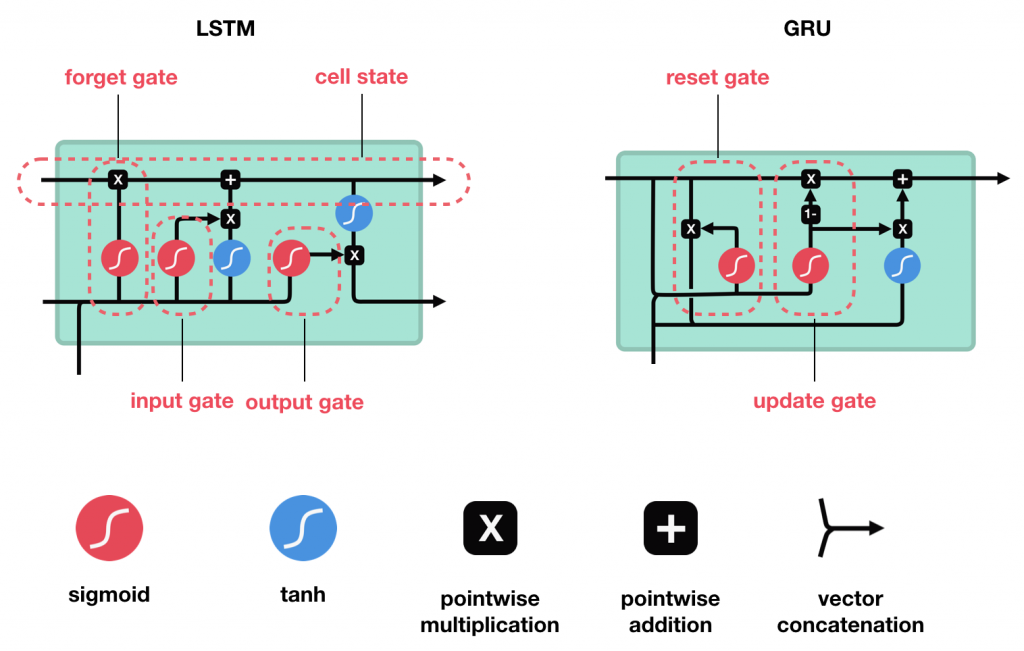
(Data Science Academy)

**How do GRUs work?**

**A) Data Input:** At each time step, the GRU receives an input from the current data sequence and the hidden (or previous state) information from the previous step.

**B) Update Gate:** The first step in the GRU is the update gate. This gate decides how much information from the previous step should be passed to the next step. This is done by calculating an update vector, which ranges from 0 (no information passed) to 1 (all information passed).

**C) Reset Gate:** The next step is the reset gate. This gate decides how much new information from the current input should be combined with the information from the previous step. This is done by calculating a reset vector, which decides which units should be updated based on the current input and the previous state.

**D) Hidden State Update:** Based on the update and reset vectors, the GRU updates its hidden state. This combines retained information from the previous step with new information from the current step.

**E) Output:** Finally, the GRU produces an output based on the current hidden state, which can be used for making predictions or feeding into the next step of the sequence.

In summary, GRUs work by controlling how information is passed and updated over time, allowing the network to learn to retain important information and handle long-term dependencies in data sequences. This makes them effective in a variety of tasks such as time series prediction, natural language processing, and speech recognition.

![](https://www.deeplearningbook.com.br/wp-content/uploads/2019/09/gru4-1024x835.png)
(Data Science Academy)

**GRU capacity**

The ability of GRU (Gated Recurrent Unit) lies in its ability to deal with problems of long-term temporal dependencies in data sequences, while maintaining a simpler structure compared to other architectures such as LSTM (Long Short-Term Memory).

Here are some of the key capabilities of GRUs:

**1. Handle Long-Term Dependencies:** GRUs are designed to better handle long-term dependencies in data sequences, allowing the network to capture relevant information even in long sequences.

**2. Avoid Gradient Vanishing:** Like LSTMs, GRUs are designed to avoid gradient vanishing issues when training recurrent neural networks, which helps in learning more complex temporal dependencies.

**3. Simple Gate Structure:** GRUs have a simpler gate structure compared to LSTMs, which makes them faster to train and less susceptible to overfitting, especially on smaller datasets.

**4. Computational Efficiency:** Due to their simplified structure, GRUs are more computationally efficient than LSTMs, making them an attractive choice for real-time applications and resource-constrained devices.

**5. Adaptability:** GRUs are highly adaptable to a variety of sequence prediction and modeling tasks, and can be easily integrated into more complex deep neural network architectures.

These capabilities make GRUs a popular choice in a variety of applications, including time series forecasting, natural language processing, speech recognition, and more.

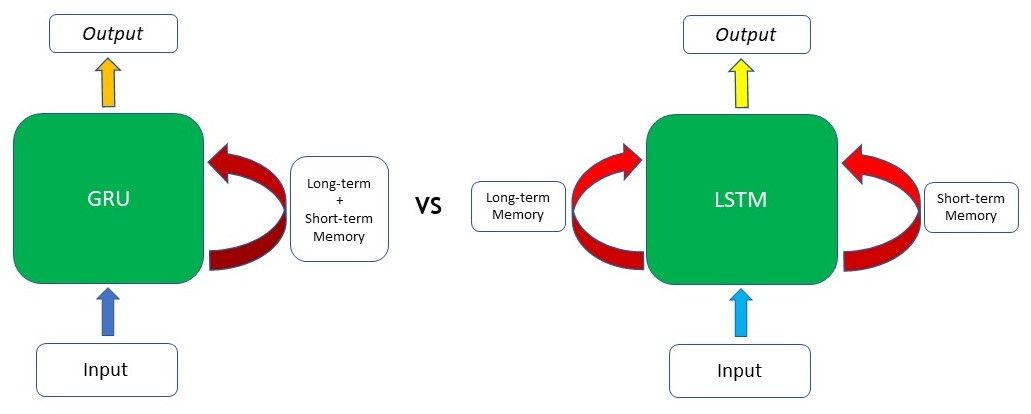
(Data Science Academy)

In [ ]:
# Load data
data = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')

# Handle missing values
data.fillna(method='ffill', inplace=True)

In [ ]:
# Encode categorical variables
label_encoders = {}
for column in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

In [ ]:
# Define independent variables (X) and target variable (y)
X = data.drop(['SalePrice', 'Id'], axis=1)
y = data['SalePrice']

In [ ]:
# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Normalize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Here, we apply the Standard Scaler to the data feeding into our neural network as part of the normalization process. The Standard Scaler is a common data preprocessing technique that helps ensure different features have the same scale, thereby preventing any one feature from having disproportionate weight during neural network training. By normalizing the data, we ensure they are centered around zero and have unit variance, which can lead to more stable training and faster model convergence. Additionally, data normalization can help avoid issues such as exploding or vanishing gradients during training. Therefore, by applying the Standard Scaler, we are appropriately preparing our input data to ensure optimal performance of our neural network

In [ ]:
# Reset format so that it is compatible with GRU (3D tensor)
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Create the model
model2 = Sequential()
model2.add(GRU(64, input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu'))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(1))

# Compile the model
model2.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Model summary
model2.summary()

**Reset format:** This line is reshaping the training and test data to be compatible with the input expected by the GRU layer. It adds an additional dimension to indicate time (sequence).

**Create the model:** Here, the neural network model is being created. It starts with a GRU layer with 64 units (neurons). The activation function used is ReLU (Rectified Linear Unit). The GRU layer is followed by a dense layer with 32 units and ReLU activation. Finally, there's an output dense layer with 1 unit, which has no specified activation function, implying it's for regression since the output will be a continuous value.

**Compile the model:** The model is compiled here, which means defining the optimizer to be used (in this case, 'adam'), the loss function (in this case, 'mse', which stands for mean squared error), and which metrics will be monitored during training (in this case, just the mean absolute error, 'mae').

**Model summary:** Finally, a summary of the model is shown, which includes all the defined layers, the number of trainable parameters, and other relevant information about the neural network architecture.

In [ ]:
# Train the model
history2 = model2.fit(X_train, y_train, epochs=500, batch_size=32, validation_split=0.2, verbose=1)

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(12, 5))

# Loss graph
plt.subplot(1, 2, 1)
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(False)

# MAE Chart
plt.subplot(1, 2, 2)
plt.plot(history2.history['mae'], label='Train MAE')
plt.plot(history2.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Training and Validation MAE')
plt.legend()
plt.grid(False)

plt.show()

In [ ]:
# Evaluate the model
loss, mae = model2.evaluate(X_test, y_test, verbose=0)
print(f'Test MAE: {mae}')

In [ ]:
# Make predictions
y_pred = model2.predict(X_test)

In [ ]:
# View results
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Add the red line
plt.xlabel('Real Prices')
plt.ylabel('Predicted Prices')
plt.title('Real vs Predicted Prices - ANN GRU')
plt.grid(False)
plt.show()

In [ ]:
# Make predictions on the test dataset
predictions2 = model2.predict(X_test)

# Display some predictions
for i in range(25):
    print(f'Predicted price for house {i+1}: ${predictions2[i][0]:.2f}')

In [ ]:
# Calculate additional metrics
predictions_train = model2.predict(X_train)
mae_train = mean_absolute_error(y_train, predictions_train)
r2_train_ANN_GRU = r2_score(y_train, predictions_train)

print(f'Mean Absolute Error (Train): {mae_train}')
print(f'R-squared (Train): {r2_train_ANN_GRU}')

In [ ]:
# Upload the sample_submission file
sample_submission = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv')

# Ensure that sample_submission has the same number of lines as X_test
len(sample_submission) == len(predictions)

# Fill the submission file with predictions
sample_submission['SalePrice'] = predictions

# Save the file ready for submission
sample_submission.to_csv('sample_submission_grau_regression_2.csv', index=False)

print('Submission file saved successfully!')

## **3) Recurrent neural network with LSTM architecture**

Here, we implement the latest neural network with LSTM architecture. Additionally, we optimize the hyperparameters to enhance the model's accuracy. We also develop an intuitive user interface to facilitate interaction with the system. All these efforts have resulted in a significant improvement in our system's performance compared to previous versions. 

## LSTM architecture

The LSTM (Long Short-Term Memory) architecture is a specific type of recurrent neural network (RNN) designed to handle sequence problems and long-term memory. Unlike traditional neural networks, which may struggle with long-term dependencies in sequential data, LSTMs are capable of learning and retaining information over longer temporal sequences. This architecture consists of memory units called 'memory cells', which have three main gates: the input gate, the forget gate, and the output gate. These gates control the flow of information within the memory cell, enabling the LSTM to learn to remember or forget information as needed during sequence processing. LSTMs are widely used in a variety of natural language processing (NLP) tasks such as machine translation, sentiment analysis, text generation, and more, due to their ability to capture long-term dependencies in sequential data. They are also applied in other domains such as time series analysis, speech recognition, and audio processing

In [ ]:
# Load data
data = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')

In [ ]:
# Handle missing values
data.fillna(method='ffill', inplace=True)

# Encode categorical variables
label_encoders = {}

for column in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

We applied the Label Encoder to encode categorical variables, ensuring a proper numerical representation for these data. Additionally, we implemented the removal of null values within the dataset, ensuring the integrity and quality of the data used in the modeling process.

In [ ]:
# Define independent variables (X) and target variable (y)
X = data.drop(['SalePrice', 'Id'], axis=1)
y = data['SalePrice']

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Here, we performed the split of the dataset into training and testing sets, aiming to evaluate the model's performance on unseen data during training. Additionally, we applied cross-validation techniques to ensure robust evaluation and prevent overfitting.

In [ ]:
# Normalize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reset format so that it is compatible with LSTM (3D tensor)
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Viewing
scaler

We applied data normalization as part of preprocessing, preparing them to feed into the LSTM architecture neural network. Additionally, we tuned the network's hyperparameters to optimize the model's performance, ensuring better fitting to the data and more efficient convergence during training.

In [ ]:
# Creating LSTM neural network
model3 = Sequential()
model3.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu'))
model3.add(Dense(32, activation='relu'))
model3.add(Dense(1))

# Compile the model
model3.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Summary
model3.summary()

**model3 = Sequential():** Here, we are initializing an instance of the sequential model. The sequential model is a linear stack of layers, where each layer has exactly one input tensor and one output tensor.

**model3.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), activation='relu')):** We add an LSTM layer to the network with 64 memory units. The activation function used is 'relu'. The input_shape parameter specifies the shape of the input data, which in this case is the format of the training samples (number_of_samples, number_of_time_steps, number_of_features).

**Adding Dense Layers:** model3.add(Dense(32, activation='relu')): We add a dense (fully connected) layer with 32 neurons and the 'relu' activation function. This layer receives as input the output vectors of the LSTM layer.

**model3.add(Dense(1)):** We add a dense output layer with a single neuron. We don't specify an activation function here, which means it will 

be a linear activation by default.

**Compiling the model: model3.compile(optimizer='adam', loss='mse', metrics=['mae']):** We compile the model by specifying the optimizer (adam), the loss function (mse, Mean Squared Error) and the metrics to be be used (mae, Mean Absolute Error) for evaluation during training.

Model summary:

**model3.summary():** This line displays a summary of the model, showing the neural network architecture, the number of parameters in each layer and the total trainable parameters in the model. This is useful for visualizing the model structure and ensuring everything is set up correctly.

In [ ]:
# Treinar o modelo
history3 = model3.fit(X_train, y_train, 
                      epochs=500, 
                      batch_size=32, 
                      validation_split=0.2, 
                      verbose=1)

**Model Training**

**history3 = model3.fit(X_train, y_train, epochs=500, batch_size=32, validation_split=0.2, verbose=1):** This command starts the neural network 

**training process. The arguments are:** X_train: The training input data.

**y_train:** The output labels corresponding to the training input data.

**epochs=500:** Number of training epochs, that is, how many times the model will go through the entire training set during training.

**batch_size=32:** Batch size used during training. Here, the training set is divided into batches of size 32 and each batch is used to update the network weights.

**validation_split=0.2:** The fraction of the training data to be used as the validation set. In this case, 20% of the training data is reserved for validation during training, while the remaining 80% is used for training.

**verbose=1:** Controls the level of verbosity during training. A value of 1 indicates that training progress will be displayed during training. After executing this command, the model will be trained using the provided data, and the training history will be returned and stored in the history3 variable. This history contains information about the loss and the specified metrics (in this case, MAE) in each epoch for both the training set and the validation set. This information can be used to evaluate model performance and convergence during training.

In [ ]:
# Evaluate the model
loss, mae = model3.evaluate(X_test, y_test, verbose=0)
print(f'Test MAE: {mae}')

In [ ]:
# Make predictions
y_pred = model3.predict(X_test)

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(20, 5))

# Loss graph
plt.subplot(1, 2, 1)
plt.plot(history3.history['loss'], label='Train Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(False)

# MAE Chart
plt.subplot(1, 2, 2)
plt.plot(history3.history['mae'], label='Train MAE')
plt.plot(history3.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Training and Validation MAE')
plt.legend()
plt.grid(False)

plt.show()

In [ ]:
# View results
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Add the red line
plt.xlabel('Real Prices')
plt.ylabel('Predicted Prices')
plt.title('Real vs Predicted Prices')
plt.grid(False)
plt.show()

Here, we see a linear regression plot generated by the neural network with LSTM architecture. This plot illustrates the relationship between the input variables and the output variable predicted by the model. Additionally, we can observe the overall trend of the data and assess the quality of the fit performed by the neural network

In [ ]:
# Make predictions on the test dataset
predictions3 = model3.predict(X_test)

# Display some predictions
for i in range(30):
    print(f'Predicted price for house {i+1}: ${predictions3[i][0]:.2f}')

In [ ]:
# Calculate additional metrics
predictions_train = model3.predict(X_train)
mae_train = mean_absolute_error(y_train, predictions_train)
r2_train_ANN_LSTM = r2_score(y_train, predictions_train)

print(f'Mean Absolute Error (Train): {mae_train}')
print(f'R-squared (Train): {r2_train_ANN_LSTM}')

In [ ]:
# Make predictions on the test set
test_predictions = model3.predict(X_test)

# Upload the sample_submission file
sample_submission = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv')

# Ensure that sample_submission has the same number of lines as X_test
len(sample_submission) == len(test_predictions)

# Fill the submission file with predictions
sample_submission['SalePrice'] = predictions

# Save the file ready for submission
sample_submission.to_csv('sample_submission_LSTM_regression_3.csv', index=False)

print('Submission file saved successfully!')

# <div style="color:green;display:fill;border-radius:5px;background-color:#9DCDD1;font-family:Nexa;overflow:hidden"><p style="padding:20px;color:black;overflow:hidden;font-size:100%;letter-spacing:0.5px;margin:0"><b>11. </b>Final result</p></div>

In [ ]:
# Neural network result
result = pd.DataFrame({'Models': ['RNN',
                                  'ANN_GRU', 
                                  'ANN_LSTM'],
                       
                       "r2":[r2_train_RNN,
                             r2_train_ANN_GRU,
                             r2_train_ANN_LSTM]})

# Visualizing
result.head()

# <div style="color:green;display:fill;border-radius:5px;background-color:#9DCDD1;font-family:Nexa;overflow:hidden"><p style="padding:20px;color:black;overflow:hidden;font-size:100%;letter-spacing:0.5px;margin:0"><b>12. </b>Conclusion</p></div>

In this house price competition project, the first phase involved data analysis, including correlation analysis between the data variables using a heatmap graph for numeric variables. Positive correlations were observed, such as:

- OverallQual vs. SalePrice: The overall quality of materials and finishing is positively correlated with the sale price.

- GrLivArea vs. SalePrice: The above-ground living area also shows a positive correlation, indicating that homes with more living space tend to have higher prices.

- GarageCars vs. SalePrice: The number of cars the garage can accommodate shows a positive correlation with the sale price.

- GarageArea vs. SalePrice: The garage area has a positive relationship with the sale price.

- TotalBsmtSF vs. SalePrice: The total basement area is also positively correlated with the sale price.

- 1stFlrSF vs. SalePrice: The first-floor area has a positive correlation with the sale price.

Following this, scatterplot graphs were used to analyze correlations between the data variables.

The second phase involved a deeper analysis, including:

- Relationship between GrLivArea and SalePrice: A linear regression graph was utilized.

- Average of apartments per neighborhood: Another important graph was used to show the average.

- Distribution of basement, first, and second-floor areas: A graph displaying the distribution of these areas was created.

- Time series graph of apartment construction years.

In the third phase, null data verification and removal of NaN models were performed, followed by outlier verification in the target variable.The fourth phase included feature engineering, applying label encoding to convert numeric variables to categorical ones.
In the fifth phase, eight regression models were applied, including Linear Regression, Decision Tree, Random Forest, KNN, Gradient Boosting, AdaBoost, XGBoost, and LGBM Regressor. The XGBoost model performed the best with an R2 score of 67%, followed by LGBM with an R2 of 62.90%. Next, important features were plotted for each model. In the subsequent phase, neural network models with three different architectures (GRU, LSTM, ANN Regression) were applied. The GRU architecture performed exceptionally well with an R2 of 94%, followed by LSTM with 91%. Therefore, the models that showed the most adherence were XGBoost, LGBM, and the neural network. This challenge was instrumental in delving into both neural network and traditional machine learning models, along with comprehensive data analysis.

# <div style="color:green;display:fill;border-radius:5px;background-color:#9DCDD1;font-family:Nexa;overflow:hidden"><p style="padding:20px;color:black;overflow:hidden;font-size:100%;letter-spacing:0.5px;margin:0"><b>13. </b>References</p></div>

Deep Learning Book. (2024). Neural Network Architecture: Gated Recurrent Unit (GRU). Retrieved from https://www.deeplearningbook.com.br/arquitetura-de-redes-neurais-gated-recurrent-unit-gru/

# Citation

@Data Science Academy. (n.d.). Retrieved from https://www.datascienceacademy.com.br/

Montoya, A. (2016). House Prices - Advanced Regression Techniques. Kaggle. Retrieved from https://kaggle.com/competitions/house-prices-advanced-regression-techniques